# Projeto — Fase 2: Saúde Mental na Indústria de Tecnologia (OSMI, 2016–2020)

## Objetivo
Este notebook integra e analisa as pesquisas anuais da **Open Sourcing Mental Illness (OSMI)** de 2016 a 2020 e utiliza o PIB de 2016 da Fase 1 para responder às seis perguntas do estudo de caso.

O fluxo cobre explicitamente: **combinação das bases, limpeza, redução, transformação, discretização, visualização e testes estatísticos**.

### Perguntas
1. Existe diferença significativa de saúde mental entre gêneros ao longo do tempo?
2. Existe diferença significativa na busca por tratamento entre gêneros ao longo do tempo?
3. Existe diferença significativa de saúde mental entre idades ao longo do tempo?
4. Existe diferença significativa na busca por tratamento entre idades ao longo do tempo?
5. Funcionários de empresas com benefícios de saúde mental buscam mais tratamento?
6. Existe diferença significativa de saúde mental entre países mais ricos (PIB elevado) em 2016?

> **Convenção analítica:** a variável “já foi diagnosticado com uma doença mental?” é usada como indicador observável de saúde mental. Isso não equivale a medir toda a saúde mental de uma pessoa; mede apenas diagnóstico autorrelatado. Essa limitação é considerada nas conclusões.

## 1. Bibliotecas e configuração

Usaremos `pandas`/`numpy` para processamento, `matplotlib` para visualização, `scipy` para testes clássicos e `statsmodels` para análise estratificada/modelos.

In [1]:
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact, chi2
from statsmodels.stats.contingency_tables import StratifiedTable
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
warnings.filterwarnings('ignore')

ALPHA = 0.05
DATA_DIR = Path('.')
if not (DATA_DIR / '2016_f.csv').exists():
    DATA_DIR = Path('/mnt/data')
print('Diretório de dados:', DATA_DIR.resolve())

Diretório de dados: /mnt/data


## 2. Carregamento e combinação das pesquisas

As cinco pesquisas possuem as mesmas 16 colunas. Adicionamos a coluna `Ano` antes de concatená-las verticalmente. Essa preservação do ano é essencial porque as perguntas 1–4 pedem comparação “ao longo do tempo”.

In [2]:
arquivos = {ano: DATA_DIR / f'{ano}_f.csv' for ano in range(2016, 2021)}
frames = []
for ano, caminho in arquivos.items():
    temp = pd.read_csv(caminho)
    temp['Ano'] = ano
    frames.append(temp)
    print(ano, temp.shape)

df_raw = pd.concat(frames, ignore_index=True)
print('Base combinada:', df_raw.shape)
df_raw.head()

2016 (1274, 17)
2017 (669, 17)
2018 (366, 17)
2019 (290, 17)
2020 (140, 17)
Base combinada: (2739, 17)


,A sua empresa oferece beneficios referentes a saude mental como parte dos beneficios de saude?,"A sua empresa ja debateu saude mental formalmente (por exemplo, via um programa de concientizacao corporativo)?",A sua empresa oferece recursos para aprender mais sobre saude mental e alternativas para buscar ajuda?,A sua privacidade eh protegida se voce optar por um tratamento de saude mental oferecido pela sua empresa?,"Caso voce sinta a necessidade de solicitar uma licenca do trabalho devido a saude mental, quao facil ou dificil seria fazer essa solicitacao?",Voce se sentiria confortavel discutindo uma questao de saude mental com o seu chefe direto?,Voce se sentiria confortavel discutindo uma questao de saude mental com os seus pares?,O quao propenso voce estaria em dividir com amigos e familiares que voce possui uma doenca mental?,"Se voce revelou uma doenca mental para um cliente ou contato de negocio, como isso afetou voce e/ou o relacionamento?","Se voce revelou uma doenca mental para um para par ou funcionario, como isso afetou voce e/ou o relacionamento?",Idade,Genero,Qual pais voce reside?,Qual pais voce trabalha?,Voce ja foi diagnosticado com uma doenca mental?,Voce ja procurou tratamento profissional para uma doenca mental?,Ano
0,Nao elegivel,Nao,Nao,Eu nao sei,Muito Facil,Sim,Talvez,Um pouco aberto,NaN,NaN,39.0000,Masculino,United Kingdom,United Kingdom,Sim,Nao,2016
1,Nao,Sim,Sim,Sim,Facil,Sim,Talvez,Um pouco aberto,NaN,NaN,29.0000,masculino,United States,United States,Sim,Sim,2016
2,Nao,Nao,Nao,Eu nao sei,Nem facil nem dificil,Talvez,Talvez,Um pouco aberto,NaN,NaN,38.0000,Masculino,United Kingdom,United Kingdom,Nao,Sim,2016
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Neutro,Nao tenho certeza,Nao tenho certeza,43.0000,masculino,United Kingdom,United Kingdom,Sim,Sim,2016
4,Sim,Nao,Nao,Nao,Nem facil nem dificil,Nao,Talvez,Um pouco aberto,NaN,NaN,43.0000,Feminino,United States,United States,Sim,Sim,2016


In [3]:
# Checagem de compatibilidade estrutural
colunas_por_ano = {ano: tuple(pd.read_csv(caminho, nrows=0).columns) for ano, caminho in arquivos.items()}
mesmas_colunas = len(set(colunas_por_ano.values())) == 1
print('Todos os anos têm as mesmas colunas?', mesmas_colunas)

Todos os anos têm as mesmas colunas? True


## 3. Diagnóstico de qualidade dos dados

Antes de alterar a base, observamos valores ausentes, cardinalidade e categorias problemáticas. Isso evita “limpezas” arbitrárias.

In [4]:
resumo_qualidade = pd.DataFrame({
    'tipo': df_raw.dtypes.astype(str),
    'nulos': df_raw.isna().sum(),
    'pct_nulos': 100 * df_raw.isna().mean(),
    'unicos': df_raw.nunique(dropna=True)
}).sort_values('pct_nulos', ascending=False)
resumo_qualidade

,tipo,nulos,pct_nulos,unicos
"Se voce revelou uma doenca mental para um cliente ou contato de negocio, como isso afetou voce e/ou o relacionamento?",object,2543,92.8441,6
"Se voce revelou uma doenca mental para um para par ou funcionario, como isso afetou voce e/ou o relacionamento?",object,2315,84.5199,7
Voce ja foi diagnosticado com uma doenca mental?,object,812,29.6459,2
A sua empresa oferece beneficios referentes a saude mental como parte dos beneficios de saude?,object,424,15.4801,5
"A sua empresa ja debateu saude mental formalmente (por exemplo, via um programa de concientizacao corporativo)?",object,424,15.4801,3
"Caso voce sinta a necessidade de solicitar uma licenca do trabalho devido a saude mental, quao facil ou dificil seria fazer essa solicitacao?",object,424,15.4801,7
Voce se sentiria confortavel discutindo uma questao de saude mental com o seu chefe direto?,object,424,15.4801,3
A sua privacidade eh protegida se voce optar por um tratamento de saude mental oferecido pela sua empresa?,object,424,15.4801,3
A sua empresa oferece recursos para aprender mais sobre saude mental e alternativas para buscar ajuda?,object,424,15.4801,3
Voce se sentiria confortavel discutindo uma questao de saude mental com os seus pares?,object,424,15.4801,3


In [5]:
# Ausência da variável de diagnóstico por ano
COL_DIAG = 'Voce ja foi diagnosticado com uma doenca mental?'
COL_TREAT = 'Voce ja procurou tratamento profissional para uma doenca mental?'
COL_GENDER = 'Genero'
COL_AGE = 'Idade'
COL_COUNTRY = 'Qual pais voce reside?'
COL_BENEFIT = 'A sua empresa oferece beneficios referentes a saude mental como parte dos beneficios de saude?'

pd.DataFrame({
    'n': df_raw.groupby('Ano').size(),
    'diagnostico_observado': df_raw.groupby('Ano')[COL_DIAG].count(),
    'diagnostico_pct_ausente': 100 * df_raw.groupby('Ano')[COL_DIAG].apply(lambda s: s.isna().mean()),
    'tratamento_observado': df_raw.groupby('Ano')[COL_TREAT].count()
})

,n,diagnostico_observado,diagnostico_pct_ausente,tratamento_observado
Ano,,,,
2016,1274,1274,0.0000,1274
2017,669,309,53.8117,669
2018,366,176,51.9126,366
2019,290,131,54.8276,290
2020,140,37,73.5714,140


### Decisão sobre valores nulos

- **Diagnóstico:** não será imputado. A ausência é muito alta depois de 2016 e inventar “Sim/Não” por imputação alteraria diretamente a variável-resposta das perguntas 1, 3 e 6. Usaremos **análise de casos completos** para cada teste que depende de diagnóstico e reportaremos a limitação.
- **Tratamento:** não apresenta valores ausentes nos cinco anos.
- **Gênero:** respostas nulas ou livres/ambíguas serão mantidas como categoria separada; a inferência principal entre Masculino/Feminino usa apenas respostas claramente classificáveis, porque as demais categorias têm contagens pequenas e gerariam células esparsas.
- **Idade:** valores incompatíveis com colaboradores adultos serão convertidos em `NaN`, não “corrigidos” por adivinhação.
- **Benefícios:** “Eu não sei”, “Não elegível” e ausentes serão excluídos do teste causal-associativo da pergunta 5, pois não significam “Não”.

## 4. Limpeza e transformação

### 4.1 Gênero
Há dezenas de grafias (`Masculino`, `masculino`, `M`, etc.) e respostas livres. Padronizamos apenas respostas inequivocamente masculinas ou femininas. As demais são preservadas como `Outro/nao binario`, evitando inferência indevida sobre identidade.

In [6]:
def normalizar_texto(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    s = ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))
    return re.sub(r'\s+', ' ', s)

def normalizar_genero(x):
    s = normalizar_texto(x)
    if not s:
        return 'Nao informado'
    masculino = {
        'masculino','m','homem','cisgenero masculino','cara','sexo e masculino',
        'masculino.','mascolino','eu sou um homem!'
    }
    feminino = {
        'feminino','f','mulher','cisgenero feminino','cisgenero mulher','fem',
        'femininu','me identifico como mulher','feminino/mulher','meu sexo e feminino'
    }
    if s in masculino:
        return 'Masculino'
    if s in feminino:
        return 'Feminino'
    return 'Outro/nao binario'

df = df_raw.copy()
df['Genero_padrao'] = df[COL_GENDER].map(normalizar_genero)
df['Genero_padrao'].value_counts(dropna=False)

Genero_padrao
Masculino            1856
Feminino              774
Outro/nao binario      89
Nao informado          20
Name: count, dtype: int64

### 4.2 Variáveis binárias
Transformamos “Sim/Não” em 1/0 apenas para facilitar taxas, modelos e testes. O valor original continua disponível.

In [7]:
df['Diagnostico'] = df[COL_DIAG].map({'Sim': 1, 'Nao': 0})
df['Tratamento'] = df[COL_TREAT].map({'Sim': 1, 'Nao': 0})

print(df[['Diagnostico','Tratamento']].isna().sum())

Diagnostico    812
Tratamento       0
dtype: int64


### 4.3 Idade: limpeza e discretização
A base contém idades como 0, 3, 5, 15, 17, 99 e 323. Como o estudo trata de colaboradores e não há informação para corrigir esses valores, adotamos a faixa plausível **18–80 anos** e transformamos os demais em ausentes.

Para cumprir a etapa de tornar os dados discretos e facilitar interpretação, criamos as faixas: 18–24, 25–34, 35–44, 45–54 e 55–80.

In [8]:
df['Idade_limpa'] = pd.to_numeric(df[COL_AGE], errors='coerce')
invalidas = ~df['Idade_limpa'].between(18, 80)
print('Idades marcadas como inválidas:', df.loc[invalidas, COL_AGE].tolist())
df.loc[invalidas, 'Idade_limpa'] = np.nan

bins = [18, 25, 35, 45, 55, 81]
labels = ['18–24', '25–34', '35–44', '45–54', '55–80']
df['Faixa_etaria'] = pd.cut(df['Idade_limpa'], bins=bins, labels=labels, right=False)
df['Faixa_etaria'].value_counts(sort=False)

Idades marcadas como inválidas: [17.0, 99.0, 323.0, 3.0, 15.0, 0.0, 5.0]


Faixa_etaria
18–24     222
25–34    1255
35–44     895
45–54     280
55–80      80
Name: count, dtype: int64

### 4.4 Redução dos dados
Criamos uma base analítica apenas com variáveis necessárias às seis perguntas. Reduzir colunas diminui ruído e deixa as operações auditáveis sem apagar a base original (`df_raw`).

In [9]:
colunas_analiticas = [
    'Ano', COL_GENDER, 'Genero_padrao', COL_AGE, 'Idade_limpa', 'Faixa_etaria',
    COL_COUNTRY, COL_DIAG, 'Diagnostico', COL_TREAT, 'Tratamento', COL_BENEFIT
]
df_a = df[colunas_analiticas].copy()
print(df_a.shape)
df_a.head()

(2739, 12)


,Ano,Genero,Genero_padrao,Idade,Idade_limpa,Faixa_etaria,Qual pais voce reside?,Voce ja foi diagnosticado com uma doenca mental?,Diagnostico,Voce ja procurou tratamento profissional para uma doenca mental?,Tratamento,A sua empresa oferece beneficios referentes a saude mental como parte dos beneficios de saude?
0,2016,Masculino,Masculino,39.0000,39.0000,35–44,United Kingdom,Sim,1.0000,Nao,0,Nao elegivel
1,2016,masculino,Masculino,29.0000,29.0000,25–34,United States,Sim,1.0000,Sim,1,Nao
2,2016,Masculino,Masculino,38.0000,38.0000,35–44,United Kingdom,Nao,0.0000,Sim,1,Nao
3,2016,masculino,Masculino,43.0000,43.0000,35–44,United Kingdom,Sim,1.0000,Sim,1,NaN
4,2016,Feminino,Feminino,43.0000,43.0000,35–44,United States,Sim,1.0000,Sim,1,Sim


## 5. Funções estatísticas auxiliares

- Para tabelas 2×2, usamos **qui-quadrado de independência** quando as frequências esperadas são adequadas; se alguma célula esperada for menor que 5, usamos **teste exato de Fisher**.
- Para comparar gênero controlando o ano, usamos **Cochran–Mantel–Haenszel (CMH)**, apropriado para várias tabelas 2×2 estratificadas por ano.
- Para idade contínua controlando o ano, usamos **regressão logística**, pois diagnóstico e tratamento são binários.
- Nível de significância: `α = 0,05`.

In [10]:
def teste_2x2(tab):
    chi2_stat, p_chi, dof, expected = chi2_contingency(tab)
    if (expected < 5).any():
        _, p = fisher_exact(tab.values)
        metodo = 'Fisher'
    else:
        p = p_chi
        metodo = 'Qui-quadrado'
    return metodo, p, expected

def cramer_v(tab):
    chi2_stat, _, _, _ = chi2_contingency(tab)
    n = tab.to_numpy().sum()
    r, k = tab.shape
    return np.sqrt(chi2_stat / (n * min(k-1, r-1))) if min(k-1, r-1) > 0 else np.nan

# Pergunta 1 — Saúde mental × gênero ao longo do tempo

**Hipótese nula (H0):** diagnóstico autorrelatado é independente do gênero, controlando o ano.

A análise inferencial principal compara respostas claramente padronizadas como Masculino/Feminino. As categorias `Outro/nao binario` continuam disponíveis na descrição, mas são pequenas para um teste estratificado robusto.

In [11]:
q1 = df_a[df_a['Genero_padrao'].isin(['Masculino','Feminino']) & df_a['Diagnostico'].notna()].copy()

taxas_q1 = (q1.groupby(['Ano','Genero_padrao'])['Diagnostico']
              .agg(['mean','count']).reset_index())
taxas_q1['pct_diagnosticado'] = 100 * taxas_q1['mean']
taxas_q1[['Ano','Genero_padrao','count','pct_diagnosticado']]

,Ano,Genero_padrao,count,pct_diagnosticado
0,2016,Feminino,325,65.2308
1,2016,Masculino,915,46.2295
2,2017,Feminino,118,97.4576
3,2017,Masculino,173,97.1098
4,2018,Feminino,66,98.4848
5,2018,Masculino,97,98.9691
6,2019,Feminino,49,100.0000
7,2019,Masculino,70,95.7143
8,2020,Feminino,13,84.6154
9,2020,Masculino,23,95.6522


In [12]:
resultados_q1 = []
tabelas_cmh = []
for ano in sorted(q1['Ano'].unique()):
    sub = q1[q1['Ano']==ano]
    tab = pd.crosstab(sub['Genero_padrao'], sub['Diagnostico']).reindex(
        index=['Feminino','Masculino'], columns=[0,1], fill_value=0)
    metodo, p, exp = teste_2x2(tab)
    resultados_q1.append({'Ano':ano,'n':len(sub),'Teste':metodo,'p_valor':p})
    if (tab.sum(axis=1)>0).all() and (tab.sum(axis=0)>0).all():
        tabelas_cmh.append(tab.values)

res_q1 = pd.DataFrame(resultados_q1)
res_q1

,Ano,n,Teste,p_valor
0,2016,1240,Qui-quadrado,0.0000
1,2017,291,Fisher,1.0000
2,2018,163,Fisher,1.0000
3,2019,119,Fisher,0.2672
4,2020,36,Fisher,0.5394


In [13]:
cmh_q1 = StratifiedTable(tabelas_cmh)
teste_cmh_q1 = cmh_q1.test_null_odds()
print(f'CMH: estatística={teste_cmh_q1.statistic:.4f}, p={teste_cmh_q1.pvalue:.3e}')

CMH: estatística=33.1352, p=8.597e-09


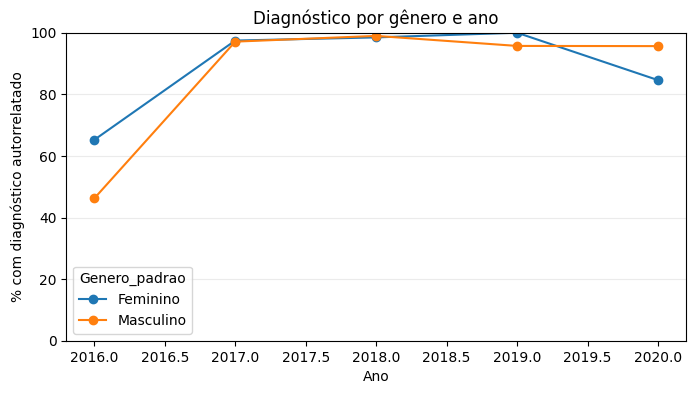

In [14]:
pivot = taxas_q1.pivot(index='Ano', columns='Genero_padrao', values='pct_diagnosticado')
ax = pivot.plot(marker='o', figsize=(8,4))
ax.set_ylabel('% com diagnóstico autorrelatado')
ax.set_title('Diagnóstico por gênero e ano')
ax.set_ylim(0,100)
ax.grid(axis='y', alpha=.25)
plt.show()

### Resposta à Pergunta 1
O teste CMH rejeita H0 (**p < 0,001**): há evidência de associação entre gênero e diagnóstico autorrelatado quando o ano é controlado. Em 2016, a diferença é particularmente clara; nos anos seguintes, a variável diagnóstico possui forte ausência e quase todos os casos observados respondem “Sim”, o que reduz drasticamente a capacidade de comparação anual.

**Conclusão:** **sim, existe evidência estatística de diferença entre gêneros no conjunto 2016–2020**, mas a interpretação temporal deve ser cautelosa por causa da não resposta de diagnóstico de 2017–2020.

# Pergunta 2 — Busca por tratamento × gênero ao longo do tempo

**H0:** busca por tratamento é independente do gênero, controlando o ano.

In [15]:
q2 = df_a[df_a['Genero_padrao'].isin(['Masculino','Feminino']) & df_a['Tratamento'].notna()].copy()
taxas_q2 = (q2.groupby(['Ano','Genero_padrao'])['Tratamento']
              .agg(['mean','count']).reset_index())
taxas_q2['pct_tratamento'] = 100 * taxas_q2['mean']
taxas_q2[['Ano','Genero_padrao','count','pct_tratamento']]

,Ano,Genero_padrao,count,pct_tratamento
0,2016,Feminino,325,76.0000
1,2016,Masculino,915,53.9891
2,2017,Feminino,206,75.7282
3,2017,Masculino,436,56.8807
4,2018,Feminino,113,76.9912
5,2018,Masculino,229,59.3886
6,2019,Feminino,83,78.3133
7,2019,Masculino,185,59.4595
8,2020,Feminino,47,40.4255
9,2020,Masculino,91,47.2527


In [16]:
resultados_q2, tabelas_cmh = [], []
for ano in sorted(q2['Ano'].unique()):
    sub = q2[q2['Ano']==ano]
    tab = pd.crosstab(sub['Genero_padrao'], sub['Tratamento']).reindex(
        index=['Feminino','Masculino'], columns=[0,1], fill_value=0)
    metodo, p, exp = teste_2x2(tab)
    resultados_q2.append({'Ano':ano,'n':len(sub),'Teste':metodo,'p_valor':p})
    tabelas_cmh.append(tab.values)

res_q2 = pd.DataFrame(resultados_q2)
res_q2

,Ano,n,Teste,p_valor
0,2016,1240,Qui-quadrado,0.0000
1,2017,642,Qui-quadrado,0.0000
2,2018,342,Qui-quadrado,0.0020
3,2019,268,Qui-quadrado,0.0042
4,2020,138,Qui-quadrado,0.5595


In [17]:
cmh_q2 = StratifiedTable(tabelas_cmh)
teste_cmh_q2 = cmh_q2.test_null_odds()
print(f'CMH: estatística={teste_cmh_q2.statistic:.4f}, p={teste_cmh_q2.pvalue:.3e}')

CMH: estatística=79.7108, p=0.000e+00


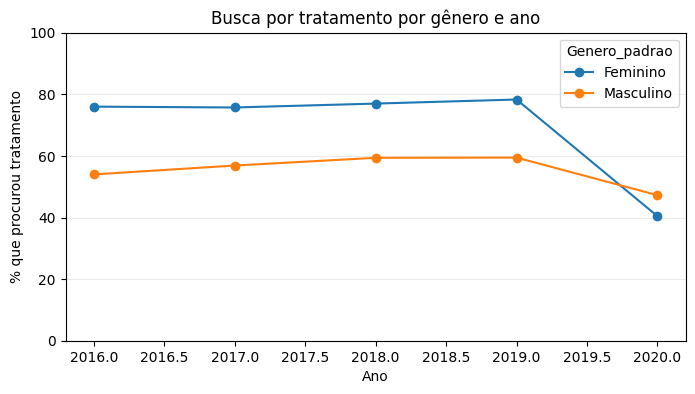

In [18]:
pivot = taxas_q2.pivot(index='Ano', columns='Genero_padrao', values='pct_tratamento')
ax = pivot.plot(marker='o', figsize=(8,4))
ax.set_ylabel('% que procurou tratamento')
ax.set_title('Busca por tratamento por gênero e ano')
ax.set_ylim(0,100)
ax.grid(axis='y', alpha=.25)
plt.show()

### Resposta à Pergunta 2
O CMH apresenta **p < 0,001**, indicando associação significativa entre gênero e busca por tratamento ao controlar o ano. De 2016 a 2019, a taxa feminina é substancialmente maior; em 2020 essa diferença não é significativa e as taxas se aproximam/invertem.

**Conclusão:** **sim, há diferença significativa na busca por tratamento entre gêneros no período**, embora o padrão de 2020 seja diferente dos anos anteriores.

# Pergunta 3 — Saúde mental × idade ao longo do tempo

A idade será examinada de duas formas:
1. **faixas etárias** (discretização), para interpretação visual/descritiva;
2. **idade contínua em regressão logística ajustada por ano**, para evitar perda de informação e testar o efeito linear da idade.

**H0 do modelo:** coeficiente da idade = 0 após controlar o ano.

In [19]:
q3 = df_a[df_a['Diagnostico'].notna() & df_a['Idade_limpa'].notna()].copy()
faixas_q3 = q3.groupby(['Ano','Faixa_etaria'], observed=False)['Diagnostico'].agg(['mean','count']).reset_index()
faixas_q3['pct_diagnosticado'] = 100*faixas_q3['mean']
faixas_q3.head(15)

,Ano,Faixa_etaria,mean,count,pct_diagnosticado
0,2016,18–24,0.4818,110,48.1818
1,2016,25–34,0.5064,626,50.6390
2,2016,35–44,0.5129,388,51.2887
3,2016,45–54,0.6455,110,64.5455
4,2016,55–80,0.5714,35,57.1429
5,2017,18–24,0.9000,20,90.0000
6,2017,25–34,0.9797,148,97.9730
7,2017,35–44,0.9623,106,96.2264
8,2017,45–54,1.0000,26,100.0000
9,2017,55–80,1.0000,9,100.0000


In [20]:
modelo_q3 = smf.logit('Diagnostico ~ Idade_limpa + C(Ano)', data=q3).fit(disp=0)
coef = modelo_q3.params['Idade_limpa']
p = modelo_q3.pvalues['Idade_limpa']
or_idade = np.exp(coef)
ici = np.exp(modelo_q3.conf_int().loc['Idade_limpa'])
print(f'Coef. idade={coef:.5f}; OR por ano de idade={or_idade:.4f}; IC95%=[{ici.iloc[0]:.4f}, {ici.iloc[1]:.4f}]; p={p:.4f}')

Coef. idade=0.01423; OR por ano de idade=1.0143; IC95%=[1.0011, 1.0278]; p=0.0339


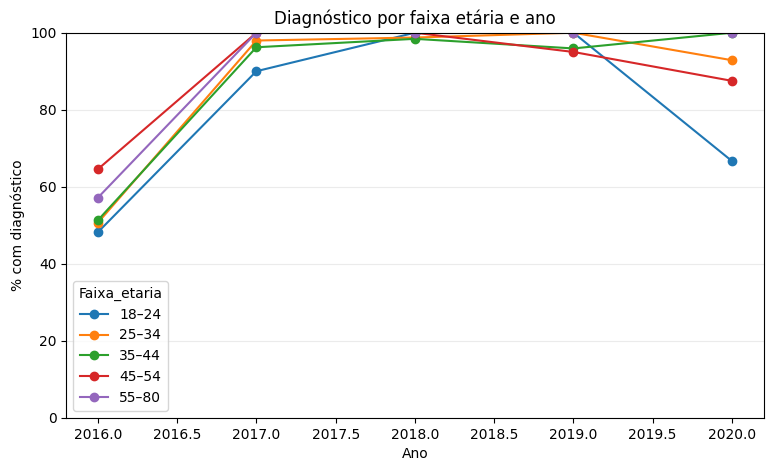

In [21]:
pivot = faixas_q3.pivot(index='Ano', columns='Faixa_etaria', values='pct_diagnosticado')
ax = pivot.plot(marker='o', figsize=(9,5))
ax.set_ylabel('% com diagnóstico')
ax.set_title('Diagnóstico por faixa etária e ano')
ax.set_ylim(0,100)
ax.grid(axis='y', alpha=.25)
plt.show()

### Resposta à Pergunta 3
No modelo logístico ajustado por ano, a idade tem **p ≈ 0,034** e OR ≈ **1,014 por ano de idade**. Isso indica um efeito positivo pequeno: cada ano adicional de idade está associado a aproximadamente 1,4% de aumento nas odds de diagnóstico, mantendo o ano constante.

**Conclusão:** **sim, há evidência estatística de associação entre idade e diagnóstico**, mas o efeito é pequeno e novamente limitado pela grande ausência de diagnóstico depois de 2016. Não se deve interpretar essa associação como causal.

# Pergunta 4 — Busca por tratamento × idade ao longo do tempo

Aplicamos o mesmo desenho: faixas etárias para descrição e regressão logística com idade contínua, controlando o ano.

In [22]:
q4 = df_a[df_a['Tratamento'].notna() & df_a['Idade_limpa'].notna()].copy()
faixas_q4 = q4.groupby(['Ano','Faixa_etaria'], observed=False)['Tratamento'].agg(['mean','count']).reset_index()
faixas_q4['pct_tratamento'] = 100*faixas_q4['mean']

modelo_q4 = smf.logit('Tratamento ~ Idade_limpa + C(Ano)', data=q4).fit(disp=0)
coef = modelo_q4.params['Idade_limpa']
p = modelo_q4.pvalues['Idade_limpa']
or_idade = np.exp(coef)
ici = np.exp(modelo_q4.conf_int().loc['Idade_limpa'])
print(f'Coef. idade={coef:.5f}; OR por ano de idade={or_idade:.4f}; IC95%=[{ici.iloc[0]:.4f}, {ici.iloc[1]:.4f}]; p={p:.4f}')

Coef. idade=0.01011; OR por ano de idade=1.0102; IC95%=[1.0008, 1.0196]; p=0.0325


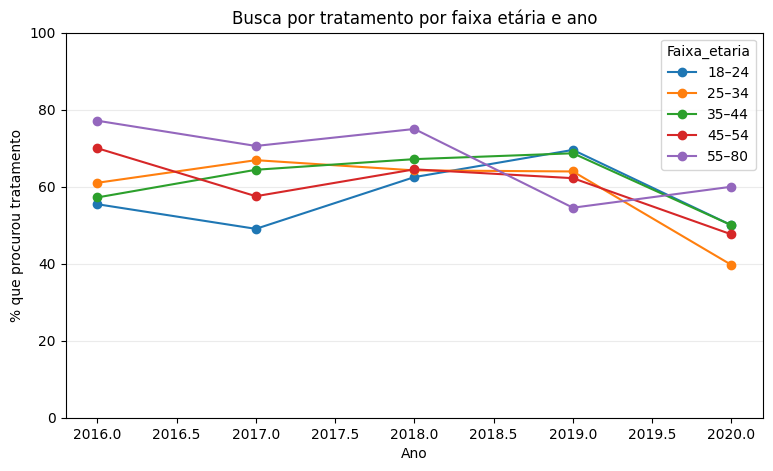

In [23]:
pivot = faixas_q4.pivot(index='Ano', columns='Faixa_etaria', values='pct_tratamento')
ax = pivot.plot(marker='o', figsize=(9,5))
ax.set_ylabel('% que procurou tratamento')
ax.set_title('Busca por tratamento por faixa etária e ano')
ax.set_ylim(0,100)
ax.grid(axis='y', alpha=.25)
plt.show()

### Resposta à Pergunta 4
O coeficiente de idade é significativo no modelo ajustado por ano (**p ≈ 0,032**), com OR ≈ **1,010 por ano**. O tamanho de efeito é pequeno: aproximadamente 1% de aumento nas odds de buscar tratamento para cada ano adicional de idade, mantendo o ano constante.

**Conclusão:** **há uma associação estatisticamente significativa, porém pequena, entre idade e busca por tratamento** no conjunto 2016–2020.

# Pergunta 5 — Benefícios de saúde mental × busca por tratamento

Para responder “funcionários de empresas que possuem benefícios buscam mais tratamento?”, comparamos somente respostas claras `Sim` e `Não` para benefício. `Eu não sei`, `Não elegível` e nulos não são recodificados como `Não`.

**H0:** benefício e busca por tratamento são independentes.

In [24]:
q5 = df_a[df_a[COL_BENEFIT].isin(['Sim','Nao'])].copy()
tab_q5 = pd.crosstab(q5[COL_BENEFIT], q5['Tratamento']).reindex(index=['Nao','Sim'], columns=[0,1])
metodo_q5, p_q5, exp_q5 = teste_2x2(tab_q5)
v_q5 = cramer_v(tab_q5)
taxas_q5 = q5.groupby(COL_BENEFIT)['Tratamento'].agg(['mean','count'])
taxas_q5['pct_tratamento'] = 100*taxas_q5['mean']
print(tab_q5)
print()
print(taxas_q5)
print()
print(f'Teste: {metodo_q5}; p={p_q5:.3e}; Cramer V={v_q5:.3f}')

Tratamento                                            0    1
A sua empresa oferece beneficios referentes a s...          
Nao                                                 137  158
Sim                                                 385  891

                                                     mean  count  \
A sua empresa oferece beneficios referentes a s...                 
Nao                                                0.5356    295   
Sim                                                0.6983   1276   

                                                    pct_tratamento  
A sua empresa oferece beneficios referentes a s...                  
Nao                                                        53.5593  
Sim                                                        69.8276  

Teste: Qui-quadrado; p=1.309e-07; Cramer V=0.133


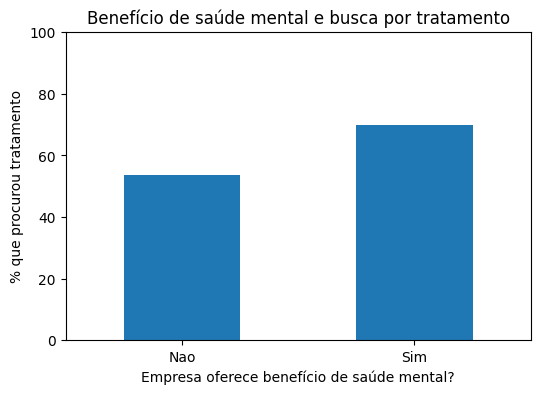

In [25]:
ax = taxas_q5.loc[['Nao','Sim'],'pct_tratamento'].plot(kind='bar', figsize=(6,4))
ax.set_ylabel('% que procurou tratamento')
ax.set_xlabel('Empresa oferece benefício de saúde mental?')
ax.set_title('Benefício de saúde mental e busca por tratamento')
ax.set_ylim(0,100)
ax.tick_params(axis='x', rotation=0)
plt.show()

### Resposta à Pergunta 5
Entre quem respondeu claramente sobre benefício, aproximadamente **69,8%** dos colaboradores com benefício procuraram tratamento, contra **53,6%** dos sem benefício. O teste de independência apresenta **p < 0,001**.

**Conclusão:** **sim, funcionários que relatam benefícios de saúde mental apresentam maior frequência de busca por tratamento**. Trata-se de associação observacional; não prova que o benefício causou a busca, pois podem existir fatores de confusão (cultura organizacional, acesso, renda, país etc.).

# Pergunta 6 — Saúde mental × PIB dos países em 2016

Carregamos o PIB da Fase 1 (`gdp_data.csv`) e selecionamos a coluna `2016`. O merge é feito pelo país de residência.

Como a pergunta exige distinguir “países mais ricos (PIB elevado)”, discretizamos o PIB usando a **mediana dos PIBs dos países únicos presentes na pesquisa de 2016**. Esse procedimento evita que o grande número de respondentes dos EUA determine o ponto de corte.

> O PIB utilizado é **PIB total em US$ correntes**, conforme o arquivo fornecido; não é PIB per capita.

In [26]:
gdp = pd.read_csv(DATA_DIR / 'gdp_data.csv')
gdp2016 = gdp[['Country Name','Country Code','2016']].rename(
    columns={'Country Name':'Pais','2016':'PIB_2016'}
)
q6 = df_a[df_a['Ano']==2016].merge(gdp2016, left_on=COL_COUNTRY, right_on='Pais', how='left')

print('Respondentes sem PIB após merge:', q6['PIB_2016'].isna().sum())
q6[[COL_COUNTRY,'PIB_2016']].drop_duplicates().sort_values('PIB_2016')

Respondentes sem PIB após merge: 0


,Qual pais voce reside?,PIB_2016
26,Netherlands,"784,060,430,240.0800"
48,Australia,"1,206,535,157,956.0300"
13,Canada,"1,527,994,741,907.4299"
76,Brazil,"1,795,700,168,991.4900"
207,India,"2,294,797,980,509.0098"
58,France,"2,472,964,344,587.1699"
0,United Kingdom,"2,699,659,680,997.2002"
22,Germany,"3,469,853,463,945.5298"
1,United States,"18,695,110,842,000.0000"


In [27]:
paises_unicos = q6[[COL_COUNTRY,'PIB_2016']].drop_duplicates().dropna()
mediana_pib = paises_unicos['PIB_2016'].median()
print(f'Mediana entre países únicos: US$ {mediana_pib:,.0f}')

q6['Grupo_PIB'] = np.where(q6['PIB_2016'] >= mediana_pib, 'PIB alto', 'PIB baixo')
q6.loc[q6['PIB_2016'].isna(), 'Grupo_PIB'] = np.nan

q6_valid = q6[q6['Diagnostico'].notna() & q6['Grupo_PIB'].notna()].copy()
tab_q6 = pd.crosstab(q6_valid['Grupo_PIB'], q6_valid['Diagnostico']).reindex(index=['PIB baixo','PIB alto'], columns=[0,1])
metodo_q6, p_q6, exp_q6 = teste_2x2(tab_q6)
v_q6 = cramer_v(tab_q6)
taxas_q6 = q6_valid.groupby('Grupo_PIB')['Diagnostico'].agg(['mean','count'])
taxas_q6['pct_diagnosticado'] = 100*taxas_q6['mean']
print(tab_q6)
print()
print(taxas_q6)
print()
print(f'Teste: {metodo_q6}; p={p_q6:.4f}; Cramer V={v_q6:.3f}')

Mediana entre países únicos: US$ 2,294,797,980,509


Diagnostico    0    1
Grupo_PIB            
PIB baixo     87   84
PIB alto     525  578

            mean  count  pct_diagnosticado
Grupo_PIB                                 
PIB alto  0.5240   1103            52.4025
PIB baixo 0.4912    171            49.1228

Teste: Qui-quadrado; p=0.4737; Cramer V=0.020


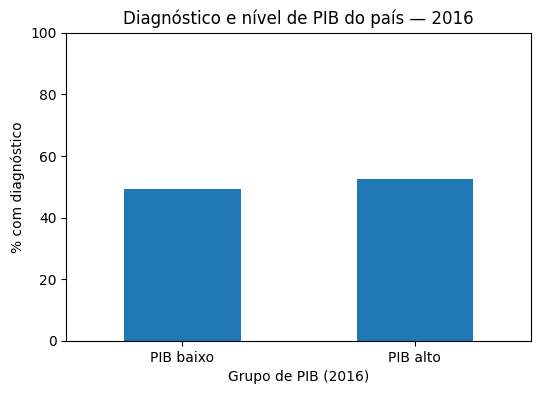

In [28]:
ax = taxas_q6.loc[['PIB baixo','PIB alto'],'pct_diagnosticado'].plot(kind='bar', figsize=(6,4))
ax.set_ylabel('% com diagnóstico')
ax.set_xlabel('Grupo de PIB (2016)')
ax.set_title('Diagnóstico e nível de PIB do país — 2016')
ax.set_ylim(0,100)
ax.tick_params(axis='x', rotation=0)
plt.show()

### Resposta à Pergunta 6
A taxa observada de diagnóstico é próxima entre os grupos (aprox. **49,1%** em PIB baixo e **52,4%** em PIB alto). O teste apresenta **p ≈ 0,474**, acima de 0,05.

**Conclusão:** **não há evidência estatística suficiente de diferença de diagnóstico entre os grupos de PIB alto e baixo em 2016**, usando o PIB total e o corte pela mediana dos países representados. “Não significativo” não significa “igualdade comprovada”; significa que esta amostra não fornece evidência suficiente para rejeitar a hipótese de independência.

# 6. Síntese final

| Pergunta | Resultado | Evidência principal |
|---|---|---|
| 1. Saúde mental × gênero | **Diferença significativa** | CMH p < 0,001; forte limitação por nulos em diagnóstico após 2016 |
| 2. Tratamento × gênero | **Diferença significativa** | CMH p < 0,001; mulheres têm maior taxa em 2016–2019 |
| 3. Saúde mental × idade | **Associação pequena, significativa** | Logit ajustado por ano: p ≈ 0,034; OR ≈ 1,014/ano |
| 4. Tratamento × idade | **Associação pequena, significativa** | Logit ajustado por ano: p ≈ 0,032; OR ≈ 1,010/ano |
| 5. Benefícios × tratamento | **Sim, maior busca com benefício** | 69,8% vs 53,6%; p < 0,001 |
| 6. Saúde mental × PIB em 2016 | **Sem diferença significativa** | 52,4% vs 49,1%; p ≈ 0,474 |

## Limitações importantes
1. **Amostra observacional e voluntária:** associações não demonstram causalidade.
2. **Diagnóstico ≠ saúde mental completa:** é um indicador autorrelatado e depende de acesso a diagnóstico.
3. **Dados ausentes de diagnóstico:** especialmente graves entre 2017 e 2020; não foram imputados para evitar viés artificial.
4. **Gênero:** respostas livres foram preservadas, mas a inferência principal binária não representa toda a diversidade de gênero.
5. **Idade:** sete valores implausíveis foram marcados como ausentes, sem tentativa de adivinhação/correção.
6. **PIB total:** países populosos tendem a ter PIB total alto; PIB per capita poderia responder a uma noção diferente de “riqueza”.
7. **Composição por país:** a amostra é concentrada em poucos países e principalmente nos Estados Unidos, portanto não representa a população mundial de trabalhadores de tecnologia.

## Conclusão geral
Os dados sustentam diferenças por gênero na frequência de diagnóstico e, mais claramente, na busca por tratamento; indicam efeitos pequenos de idade; mostram associação positiva entre benefícios corporativos e tratamento; e não oferecem evidência de diferença de diagnóstico entre grupos de PIB em 2016. As conclusões devem ser apresentadas como **associações na amostra OSMI**, não como relações causais ou estimativas populacionais universais.

## 7. Exportação opcional da base analítica tratada

A célula abaixo gera um CSV com as variáveis tratadas utilizadas nas análises, facilitando auditoria e reutilização.

In [29]:
saida = DATA_DIR / 'osmi_fase2_limpo.csv'
df_a.to_csv(saida, index=False)
print('Arquivo salvo em:', saida.resolve())

Arquivo salvo em: /mnt/data/osmi_fase2_limpo.csv
